### This is Sql project fro analysing the data with sql query

In [2]:
import pandas as pd
import sqlite3


df = pd.read_csv("/content/sale's data.csv")

# checking data

print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   InvoiceNo      15000 non-null  object 
 1   Date           15000 non-null  object 
 2   StoreID        15000 non-null  object 
 3   ProductID      15000 non-null  object 
 4   Category       15000 non-null  object 
 5   Quantity       15000 non-null  int64  
 6   UnitPrice      15000 non-null  float64
 7   Discount(%)    15000 non-null  int64  
 8   CostPerUnit    15000 non-null  float64
 9   CustomerType   15000 non-null  object 
 10  PaymentMode    15000 non-null  object 
 11  Day            15000 non-null  object 
 12  Gross_Sales    15000 non-null  float64
 13  Total_Cost     15000 non-null  float64
 14  Total_Sales    15000 non-null  float64
 15  Net_Profit     15000 non-null  float64
 16  Profit_Margin  15000 non-null  float64
 17  DayName        15000 non-null  object 
dtypes: flo

In [3]:
#connecting database

conn = sqlite3.connect('Sales.db')
df.to_sql('Sales', conn, if_exists='replace', index=False)

15000

In [4]:
#performing sql queries in dataset

#Over all performance

query = """
SELECT
    ROUND(SUM(Total_Sales),2) AS TotalSales,
    ROUND(SUM(Net_Profit),2) AS TotalProfit,
    COUNT(*) AS TotalOrders
FROM Sales;
"""

pd.read_sql(query, conn)



,TotalSales,TotalProfit,TotalOrders
0,1.929833e+08,1.399587e+08,15000


In [5]:
#checking overall sales by categories

query = """
SELECT
    Category,
    ROUND(SUM(Total_Sales),2) AS Sales,
    ROUND(SUM(Net_Profit),2) AS Profit
FROM Sales
GROUP BY Category
ORDER BY Sales DESC;
"""

pd.read_sql(query, conn)

,Category,Sales,Profit
0,Accessories,82584278.13,65624316.28
1,Shoes,64845677.89,47588118.99
2,Clothing,45553331.79,26746263.59


In [6]:
#customer type

query = """
SELECT
    CustomerType,
    COUNT(*) AS Orders,
    ROUND(SUM(Total_Sales),2) AS Sales,
    ROUND(SUM(Net_Profit),2) AS Profit
FROM Sales
GROUP BY CustomerType;
"""

pd.read_sql(query, conn)

,CustomerType,Orders,Sales,Profit
0,New,4438,5.622635e+07,40585150.36
1,Returning,10562,1.367569e+08,99373548.50


In [7]:
#payment mode analysis


query = """
SELECT
    PaymentMode,
    COUNT(*) AS Orders,
    ROUND(SUM(Total_Sales),2) AS Sales
FROM Sales
GROUP BY PaymentMode
ORDER BY Sales DESC;
"""

pd.read_sql(query, conn)

,PaymentMode,Orders,Sales
0,Card,5991,76546458.03
1,Cash,4561,58911162.16
2,Digital,4448,57525667.62


In [8]:
#sales by stores

query = """
SELECT
    StoreID,
    ROUND(SUM(Total_Sales),2) AS Sales,
    ROUND(SUM(Net_Profit),2) AS Profit
FROM Sales
GROUP BY StoreID
ORDER BY Sales DESC;
"""
pd.read_sql(query, conn)

,StoreID,Sales,Profit
0,STR018,4550113.40,3380396.15
1,STR041,4378786.23,3147465.20
2,STR048,4365419.11,3130096.77
3,STR028,4331013.08,3120117.18
4,STR008,4314659.05,3181736.07
5,STR022,4296319.95,3080474.46
6,STR013,4231350.36,3090152.87
7,STR025,4230137.47,3113890.25
8,STR044,4228627.37,3114920.49
9,STR034,4214315.07,2985656.81


In [9]:
#sales by day

query = """
SELECT
    DayName,
    ROUND(SUM(Total_Sales),2) AS Sales
FROM Sales
GROUP BY DayName
ORDER BY Sales DESC;
"""
pd.read_sql(query, conn)


,DayName,Sales
0,Saturday,33587962.76
1,Sunday,32505742.04
2,Thursday,26174201.16
3,Monday,25871599.56
4,Friday,25607575.41
5,Wednesday,24874568.79
6,Tuesday,24361638.09


In [10]:
#discount impact on sales
query = """
SELECT
    ROUND(AVG([Discount(%)]),2) AS AvgDiscount,
    ROUND(AVG(Profit_Margin),2) AS AvgProfitMargin
FROM Sales;
"""
pd.read_sql(query, conn)

,AvgDiscount,AvgProfitMargin
0,7.44,55.62


After calculating data i performed some python work with pandas for visualization

<Axes: ylabel='Category'>

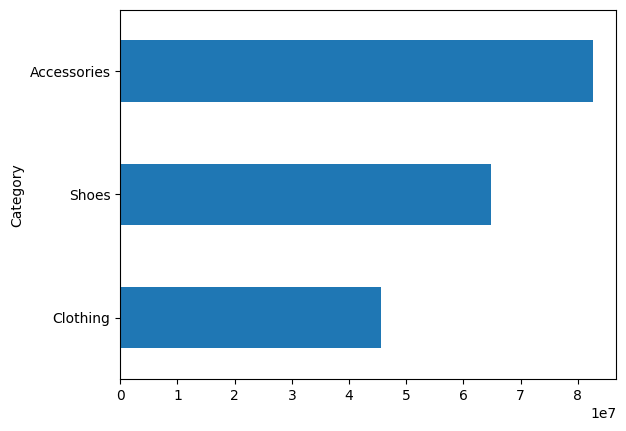

In [11]:
#Sales by category

category_sales = df.groupby('Category')['Total_Sales'].sum().sort_values()

category_sales.plot(kind='barh')

<Axes: ylabel='Category'>

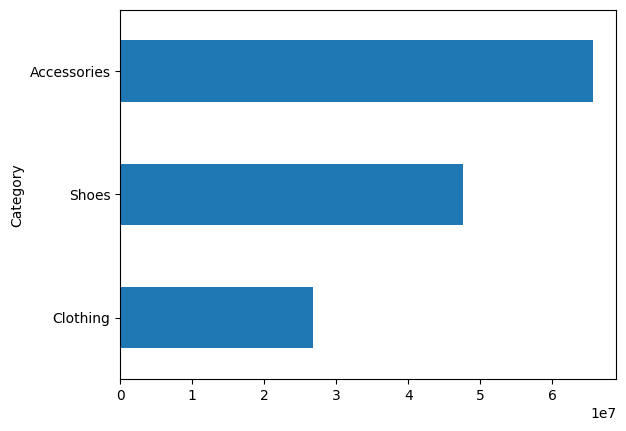

In [12]:
#Profit by Category

df.groupby('Category')['Net_Profit'].sum().sort_values().plot(kind='barh')

<Axes: xlabel='PaymentMode'>

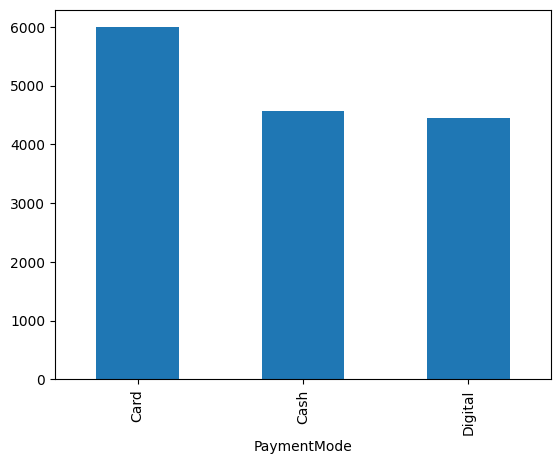

In [13]:
#Payment Mode Distribution

df['PaymentMode'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

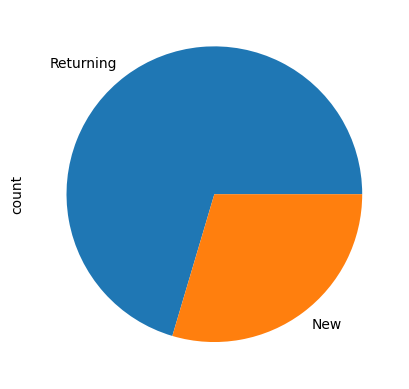

In [14]:
#Customer Type Distribution

df['CustomerType'].value_counts().plot(kind='pie')

<Axes: xlabel='Date'>

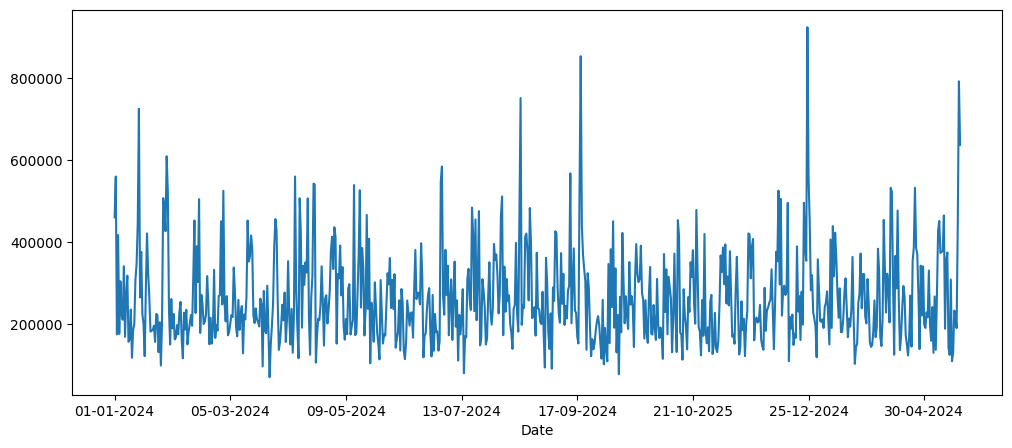

In [15]:
#for daily trend

daily_sales = df.groupby('Date')['Total_Sales'].sum()

daily_sales.plot(figsize=(12,5))

Business Performance

Total Sales: ₹192.98 Million

Total Profit: ₹139.96 Million

Total Orders: 15,000

Overall Profit Margin: 55.62%

Category Performance

Category	Sales

Accessories	₹82.58M

Shoes	₹64.85M

Clothing	₹45.55M

Accessories generated the highest sales and profit contribution.

Customer Behavior

Customer Type

Orders	Sales

Returning	10,562	₹136.76M

New	4,438	₹56.22M

Returning customers contributed approximately 71% of total sales, highlighting strong customer retention and repeat purchases.

Payment Mode	Sales

Card	₹76.55M

Cash	₹58.91M

Digital	₹57.53M

Insight: Card payments were the most preferred payment method.

Sales Trend Analysis

Day	Sales

Saturday	₹33.59M

Sunday	₹32.51M

Tuesday	₹24.36M

Insight: Weekend sales significantly outperformed weekdays, indicating higher customer activity on Saturdays and Sundays.